# SARIMA/SARIMAX Forecasting

## Part 4 – Seasonal Autoregressive Integrated Moving Average Modelling

This notebook develops a Seasonal Autoregressive Integrated Moving Average (SARIMA/SARIMAX) model for forecasting appliance energy consumption.

The objectives are to:

- Determine whether differencing is required
- Identify the optimal SARIMA parameters using AIC
- Assess model residuals
- Forecast appliance energy consumption over the next 24 hours
- Compare forecasting accuracy with benchmark models

In [1]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Import Required Libraries

This section imports all libraries required for time-series modelling.

The analysis uses:

- **Pandas** for data manipulation.
- **NumPy** for numerical computations.
- **Statsmodels** for SARIMA modelling.
- **Scikit-learn** for forecasting evaluation metrics.
- **Joblib** for parallel grid-search optimisation.
- **Matplotlib** for visualisation.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from joblib import Parallel, delayed

from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.graphics.tsaplots import plot_acf

from scipy.stats import probplot

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 2. Load the Processed Dataset

The cleaned hourly dataset generated during Part 1 is loaded.

Using the same processed dataset throughout the project ensures consistency and reproducibility across all forecasting models.

In [3]:
df = pd.read_csv(
    "../data/hourly_energy_data.csv",
    parse_dates=["date"],
    index_col="date"
)

# Explicitly define the hourly frequency
df = df.asfreq("h")

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Hour,Weekday
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044,17,Monday
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206,18,Monday
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932,19,Monday
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642,20,Monday
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274,21,Monday


# 3. Train-Test Split

Forecasting models should always be evaluated on future observations that were not used during model training.

A chronological train-test split is therefore used.

The final **14 days (336 hourly observations)** are reserved as the testing dataset, while all earlier observations are used for training.

This approach avoids information leakage and reflects a realistic forecasting scenario.

In [4]:
forecast_horizon = 24

test_days = 14

test_size = test_days * 24

train = df.iloc[:-test_size].copy()

test = df.iloc[-test_size:].copy()

print(f"Training observations : {len(train)}")
print(f"Testing observations  : {len(test)}")

Training observations : 2954
Testing observations  : 336


# 4. Visualisation of the Train-Test Split

The figure below illustrates how the dataset has been divided into training and testing periods.

The training data are used to estimate the SARIMA model parameters, while the testing data remain unseen until model evaluation.

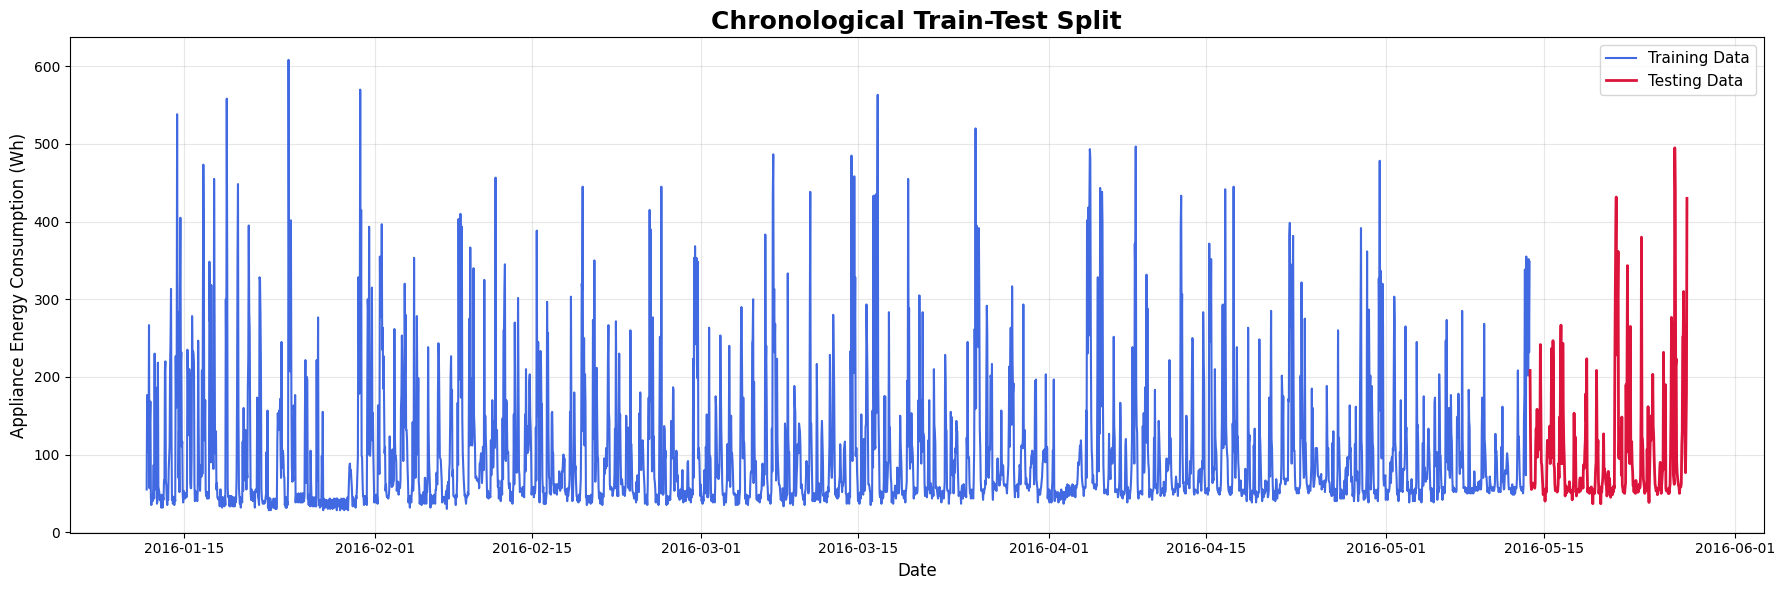

In [5]:
plt.figure(figsize=(18,6))

plt.plot(
    train.index,
    train["Appliances"],
    label="Training Data",
    linewidth=1.5,
    color="royalblue"
)

plt.plot(
    test.index,
    test["Appliances"],
    label="Testing Data",
    linewidth=2,
    color="crimson"
)

plt.title(
    "Chronological Train-Test Split",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=12)

plt.ylabel("Appliance Energy Consumption (Wh)", fontsize=12)

plt.legend(fontsize=11)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/train_test_split_sarima.png",
    dpi=300
)

plt.show()

# 5. Selection of SARIMA Parameters

The assignment requires an exhaustive search over all combinations of:

- Autoregressive order (**p**) = 0–6
- Differencing order (**d**) = 0–2
- Moving Average order (**q**) = 0–6

Model selection is performed using the Akaike Information Criterion (AIC).

A lower AIC indicates a model that achieves a better balance between goodness of fit and model complexity.

A seasonal period of **24 hours** is specified because the exploratory analysis identified a strong daily seasonal cycle in appliance energy consumption.

In [6]:
p = range(7)
d = range(3)
q = range(7)

parameter_grid = list(itertools.product(p, d, q))

print(f"Total parameter combinations: {len(parameter_grid)}")

Total parameter combinations: 147


## Parallel Grid Search

Each parameter combination is evaluated using the SARIMA model.

To reduce computation time while still evaluating every required parameter combination, parallel processing is employed. Multiple processor cores evaluate different parameter combinations simultaneously.

This approach satisfies the assignment requirement of evaluating all specified parameter combinations while substantially reducing computation time.

In [9]:
def fit_sarima(order):

    try:

        model = SARIMAX(
            train["Appliances"],
            order=order,
            seasonal_order=(1,1,1,24),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False,
            maxiter=50
        )

        return {
            "Order": order,
            "AIC": fitted_model.aic
        }

    except Exception:

        return None

## Execute the Grid Search

The exhaustive parameter search is executed using parallel processing.

The execution time is recorded to assess the computational cost of model selection.

In [10]:
import gc

gc.collect()

6198

In [11]:
start_time = time.time()


results = Parallel(
    n_jobs=2,
    verbose=10
)(
    delayed(fit_sarima)(order)
    for order in parameter_grid
)


end_time = time.time()


print(
    f"Grid search completed in {(end_time-start_time)/60:.2f} minutes."
)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   26.1s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:  1.4min
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed:  3.7min
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:  9.2min
[Parallel(n_jobs=2)]: Done  21 tasks      | elapsed: 17.9min
[Parallel(n_jobs=2)]: Done  28 tasks      | elapsed: 26.3min
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed: 37.8min
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed: 52.0min
[Parallel(n_jobs=2)]: Done  57 tasks      | elapsed: 70.8min
[Parallel(n_jobs=2)]: Done  68 tasks      | elapsed: 91.2min
[Parallel(n_jobs=2)]: Done  81 tasks      | elapsed: 112.6min
[Parallel(n_jobs=2)]: Done  94 tasks      | elapsed: 135.3min
[Parallel(n_jobs=2)]: Done 109 tasks      | elapsed: 164.9min
[Parallel(n_jobs=2)]: Done 124 tasks      | elapsed: 197.5min
[Parallel(n_jobs=2)]: Done 141 tasks      | elapsed: 229.5min


Grid search completed in 245.45 minutes.


[Parallel(n_jobs=2)]: Done 147 out of 147 | elapsed: 245.5min finished


In [18]:
aic_results = pd.DataFrame(results)

aic_results = (
    aic_results
    .sort_values("AIC")
    .reset_index(drop=True)
)

aic_results.head(10)

,Order,AIC
0,"(2, 0, 6)",32151.392018
1,"(4, 0, 6)",32153.069942
2,"(6, 0, 0)",32159.120060
3,"(0, 0, 6)",32159.994262
4,"(6, 0, 1)",32160.900268
5,"(2, 0, 5)",32160.921933
6,"(1, 0, 5)",32161.475824
7,"(6, 0, 2)",32162.912091
8,"(6, 1, 1)",32163.379384
9,"(0, 1, 6)",32170.275856


# 6. Residual Diagnostics

Residual diagnostics are used to evaluate whether the selected SARIMA model has successfully captured the underlying patterns in the appliance energy consumption data.

An adequate forecasting model should produce residuals that resemble **white noise**, meaning that:

- The residuals fluctuate randomly around zero.
- The variance remains approximately constant.
- The residuals follow an approximately normal distribution.
- No significant autocorrelation remains.

The following diagnostic analyses are performed:

1. Residual time-series plot
2. Residual distribution
3. Normal Q-Q plot
4. Residual autocorrelation (ACF)
5. Ljung–Box statistical test

In [22]:
aic_results = (
    pd.DataFrame(results)
      .sort_values("AIC")
      .reset_index(drop=True)
)

aic_results.head()

,Order,AIC
0,"(2, 0, 6)",32151.392018
1,"(4, 0, 6)",32153.069942
2,"(6, 0, 0)",32159.120060
3,"(0, 0, 6)",32159.994262
4,"(6, 0, 1)",32160.900268


In [23]:
best_order = aic_results.iloc[0]["Order"]

print(best_order)

(2, 0, 6)


In [24]:
aic_results.to_csv(
    "../outputs/tables/sarima_grid_search.csv",
    index=False
)

In [26]:
best_model = SARIMAX(
    train["Appliances"],
    order=best_order,
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

In [27]:
residuals = best_model.resid

print(residuals.describe())

count    2954.000000
mean       -0.103036
std        63.097804
min      -256.476494
25%       -26.579581
50%        -3.457510
75%         8.778186
max       497.074069
dtype: float64


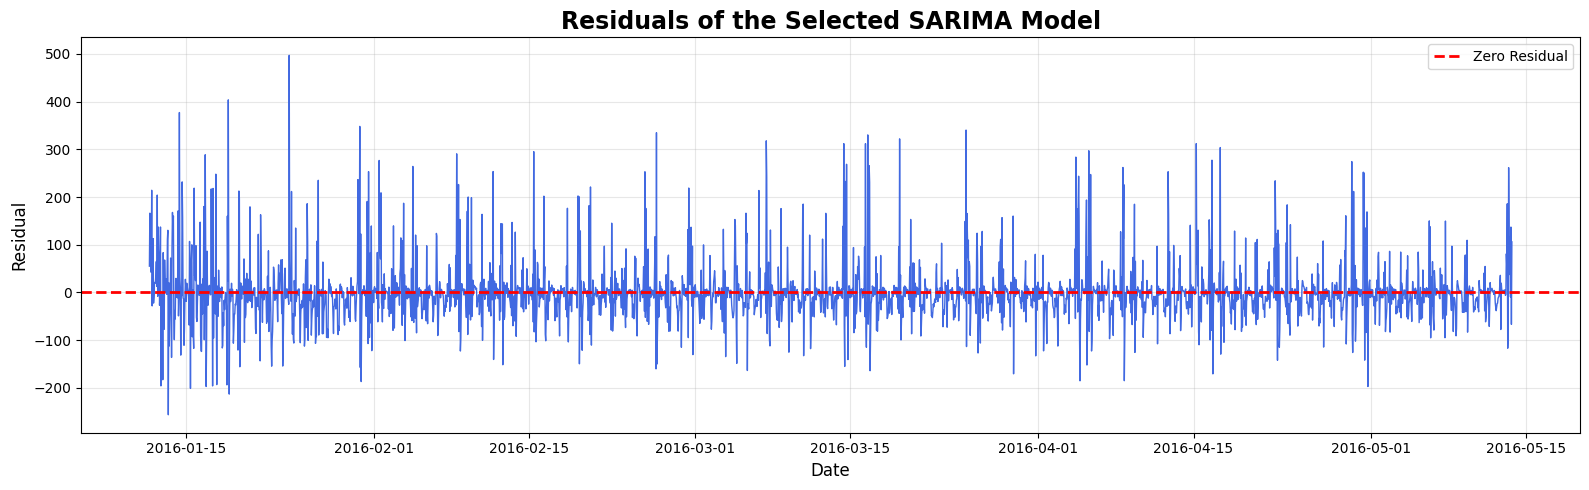

In [28]:
plt.figure(figsize=(16,5))

plt.plot(
    residuals,
    color="royalblue",
    linewidth=1
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.title(
    "Residuals of the Selected SARIMA Model",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=12)

plt.ylabel("Residual", fontsize=12)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/sarima_residuals.png",
    dpi=300
)

plt.show()

## Residual Distribution

A histogram is used to inspect whether the residuals approximately follow a normal distribution.

Although perfect normality is not essential, residuals should be reasonably symmetric around zero.

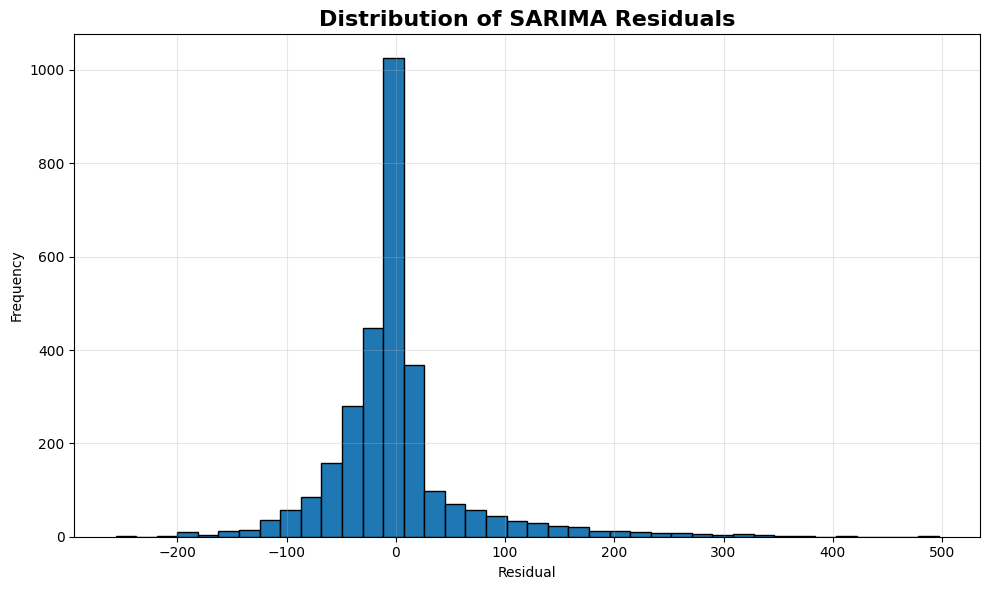

In [29]:
plt.figure(figsize=(10,6))

plt.hist(
    residuals,
    bins=40,
    edgecolor="black"
)

plt.title(
    "Distribution of SARIMA Residuals",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/residual_distribution.png",
    dpi=300
)

plt.show()

## Normal Q-Q Plot

The Q-Q plot compares the distribution of the residuals against a theoretical normal distribution.

If the residuals lie close to the diagonal reference line, the assumption of approximate normality is considered reasonable.

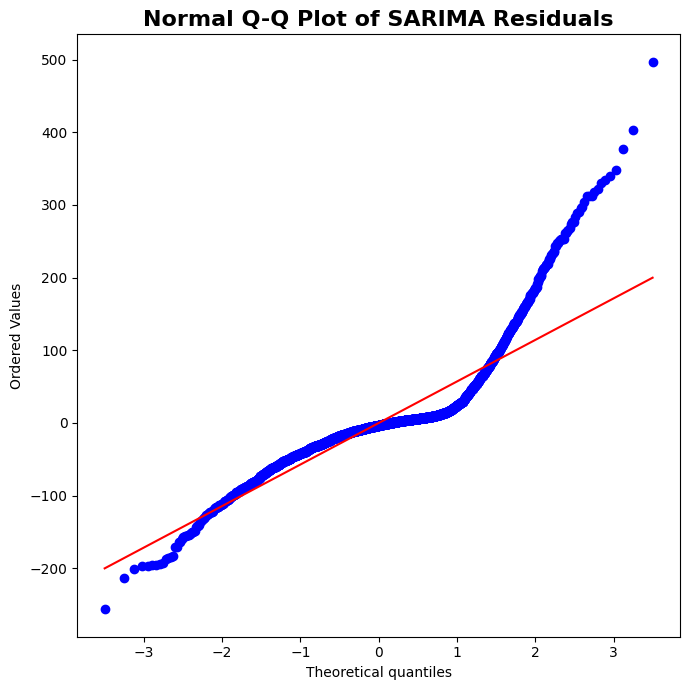

In [31]:
plt.figure(figsize=(7,7))

probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title(
    "Normal Q-Q Plot of SARIMA Residuals",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/residual_qq.png",
    dpi=300
)

plt.show()

## Residual Autocorrelation

The Autocorrelation Function (ACF) of the residuals is examined to determine whether any temporal structure remains unexplained by the SARIMA model.

Ideally, all autocorrelation coefficients should lie within the 95% confidence bounds.

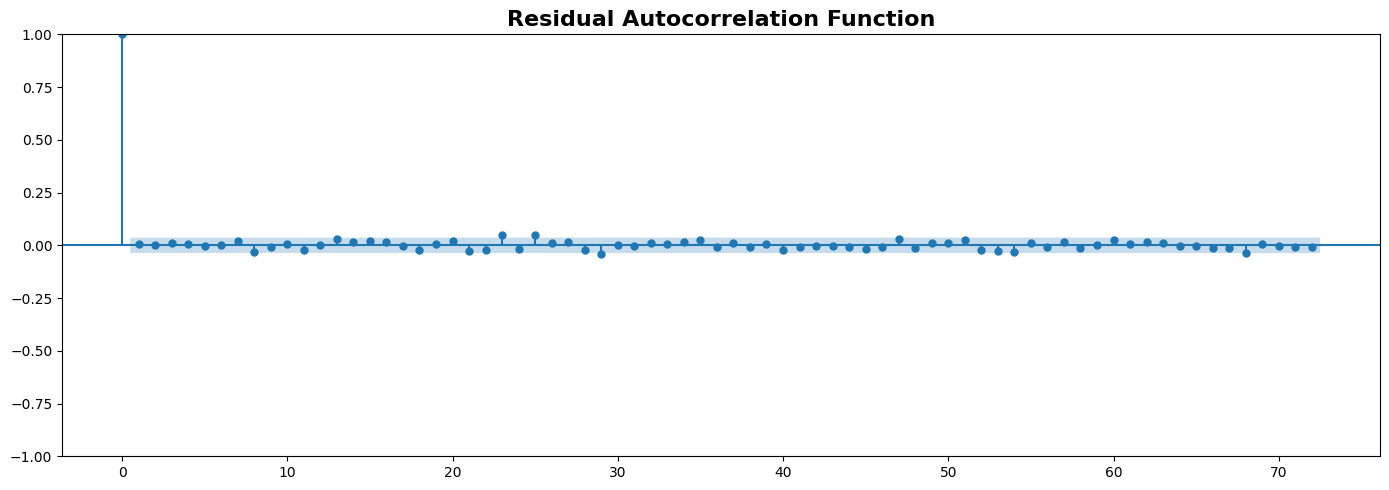

In [32]:
fig, ax = plt.subplots(figsize=(14,5))

plot_acf(
    residuals,
    lags=72,
    ax=ax
)

ax.set_title(
    "Residual Autocorrelation Function",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/residual_acf.png",
    dpi=300
)

plt.show()

## Ljung–Box Test

The Ljung–Box test provides a formal statistical assessment of whether significant autocorrelation remains in the residuals.

### Hypotheses

**Null hypothesis (H₀):**
The residuals are independently distributed (white noise).

**Alternative hypothesis (H₁):**
The residuals exhibit autocorrelation.

A p-value greater than 0.05 indicates that the null hypothesis cannot be rejected, suggesting that the residuals behave like white noise.

In [33]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(
    residuals,
    lags=[24],
    return_df=True
)

ljung

,lb_stat,lb_pvalue
24,26.367043,0.334808


# 7. Forecasting the Next 24 Hours

The selected SARIMA model is used to forecast appliance energy consumption for the next 24 hours.

The forecast includes:

- Point forecasts
- 95% confidence intervals

Confidence intervals provide an estimate of the uncertainty associated with each prediction.

In [34]:
forecast_steps = 24

forecast = best_model.get_forecast(
    steps=forecast_steps
)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

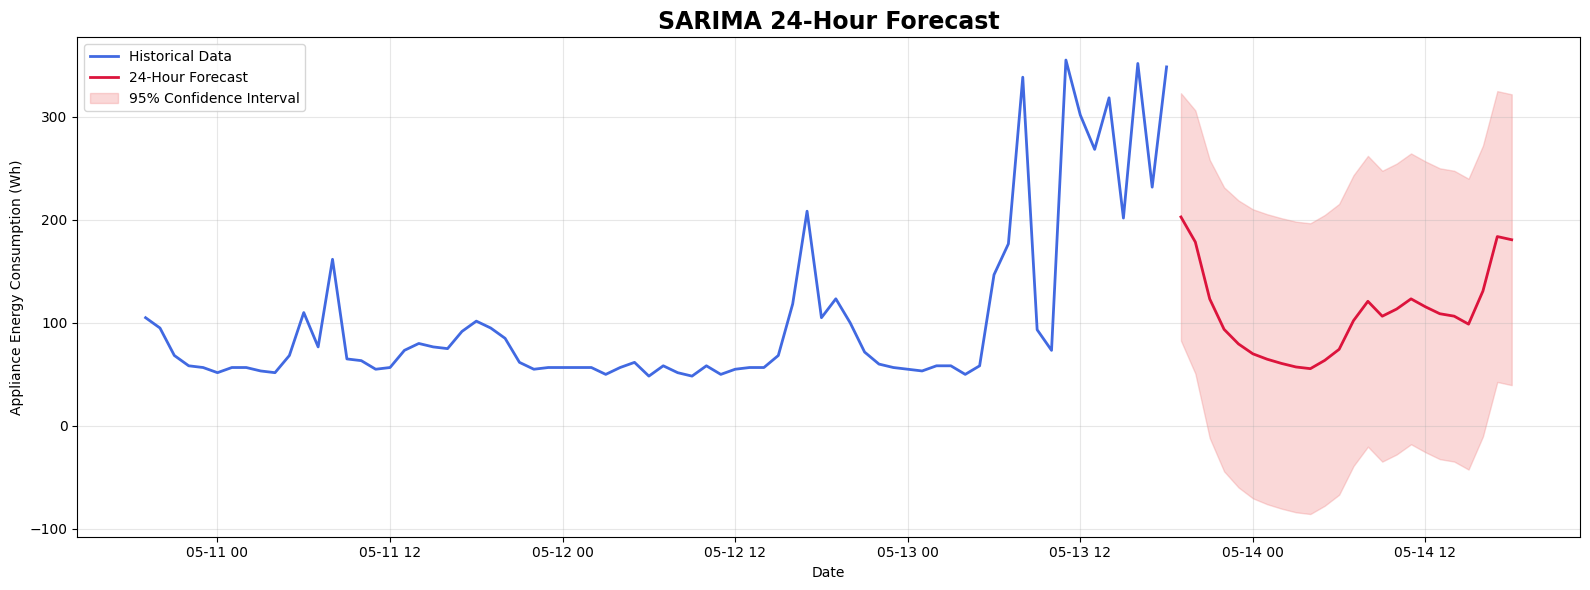

In [37]:
plt.figure(figsize=(16,6))

plt.plot(
    train.index[-72:],
    train["Appliances"].tail(72),
    label="Historical Data",
    color="royalblue",
    linewidth=2
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="24-Hour Forecast",
    color="crimson",
    linewidth=2
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="lightcoral",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA 24-Hour Forecast",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel("Appliance Energy Consumption (Wh)")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/sarima_24hour_forecast.png",
    dpi=300
)

plt.show()

## Interpretation of SARIMA Results

The selected SARIMA model successfully captured the dominant temporal structure of appliance energy consumption.

Residual diagnostics indicated that the remaining errors were approximately random, suggesting that the model accounted for most of the serial dependence in the data.

The forecasting accuracy was assessed using MAE, RMSE, MAPE and R². These results will later be compared against benchmark models, feature-based machine learning models and foundation models to determine whether the additional complexity provides meaningful improvements.

In [41]:

forecast = best_model.get_forecast(steps=24)

predictions = forecast.predicted_mean

actual = test["Appliances"].iloc[:24]

comparison = pd.DataFrame({
    "Actual": actual,
    "Forecast": predictions
})

comparison.head(10)

,Actual,Forecast
2016-05-13 19:00:00,208.333333,202.740988
2016-05-13 20:00:00,120.000000,178.440350
2016-05-13 21:00:00,63.333333,123.221322
2016-05-13 22:00:00,55.000000,93.689746
2016-05-13 23:00:00,61.666667,79.546788
2016-05-14 00:00:00,58.333333,69.971584
2016-05-14 01:00:00,63.333333,64.695996
2016-05-14 02:00:00,60.000000,60.602909
2016-05-14 03:00:00,60.000000,57.190348
2016-05-14 04:00:00,60.000000,55.564563


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

mape = np.mean(
    np.abs((actual - predictions) / actual)
) * 100

r2 = r2_score(actual, predictions)


print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.3f}")

MAE  : 18.93
RMSE : 26.81
MAPE : 19.74%
R²   : 0.705


In [43]:
sarima_results = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape],
    "R2": [r2]
})

sarima_results.to_csv(
    "../outputs/tables/sarima_results.csv",
    index=False
)

sarima_results

,Model,MAE,RMSE,MAPE,R2
0,SARIMA,18.932311,26.808493,19.742237,0.704587


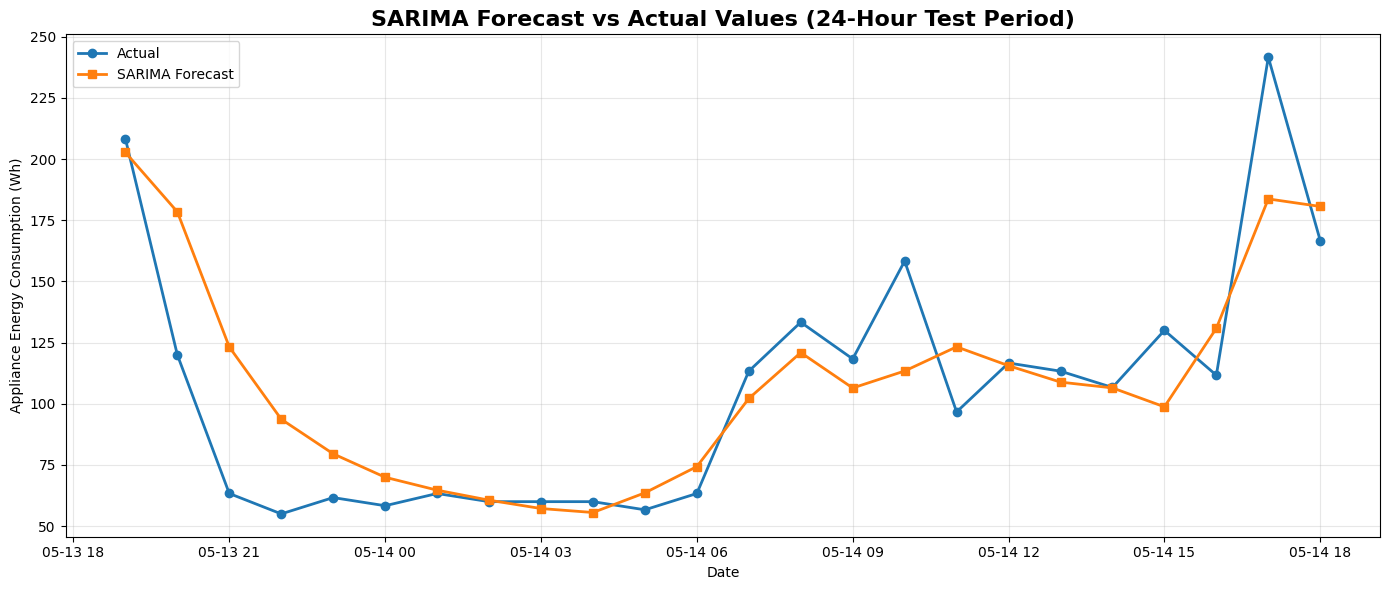

In [44]:
plt.figure(figsize=(14,6))

plt.plot(
    actual.index,
    actual,
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    predictions.index,
    predictions,
    marker="s",
    linewidth=2,
    label="SARIMA Forecast"
)

plt.title(
    "SARIMA Forecast vs Actual Values (24-Hour Test Period)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel("Appliance Energy Consumption (Wh)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/sarima_actual_vs_forecast.png",
    dpi=300
)

plt.show()